# 🔬 Thyroid Cancer Image Classification 
## Binary Classification: Benign vs Malignant
### African Leadership University — Machine Learning Pipeline Summative

---
**Model:** EfficientNetB0 (Transfer Learning)  
**Task:** Binary Image Classification  
**Dataset:** Thyroid Cancer Ultrasound Images (Kaggle)  
**Classes:** `Benign` | `Malignant`  


##  1. Install & Import Dependencies

In [9]:
!pip install tensorflow scikit-learn matplotlib seaborn opencv-python Pillow tqdm

In [10]:
import os
import shutil
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

# ✅ FIX 1: Use EfficientNet's own preprocessing function
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score, precision_score, recall_score
)

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU found  : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow : 2.21.0
GPU found  : False


##  2. Data Acquisition

In [14]:

RAW_DIR       = Path('./data/raw')
BENIGN_DIR    = RAW_DIR / 'benign'
MALIGNANT_DIR = RAW_DIR / 'malignant'

import os; os.chdir(r"C:\Users\HP\Downloads\ML_Pipeline_Summative\ML_Pipeline_Summative")
benign_imgs    = sorted(BENIGN_DIR.glob('*.jpg')) + sorted(BENIGN_DIR.glob('*.jpeg'))
malignant_imgs = sorted(MALIGNANT_DIR.glob('*.jpg')) + sorted(MALIGNANT_DIR.glob('*.jpeg'))

benign_count    = len(benign_imgs)
malignant_count = len(malignant_imgs)
total           = benign_count + malignant_count

print(f'Benign images    : {benign_count}')
print(f'Malignant images : {malignant_count}')
print(f'Total            : {total}')

imbalance_ratio = max(benign_count, malignant_count) / (min(benign_count, malignant_count) + 1e-8)
print(f'Imbalance ratio  : {imbalance_ratio:.2f}x')
if imbalance_ratio > 1.5:
    print('⚠️  Class imbalance detected — class weights will be applied automatically.')
else:
    print('✅ Classes are balanced.')

Benign images    : 1905
Malignant images : 1210
Total            : 3115
Imbalance ratio  : 1.57x
⚠️  Class imbalance detected — class weights will be applied automatically.


##  3. Exploratory Data Analysis & Visualizations

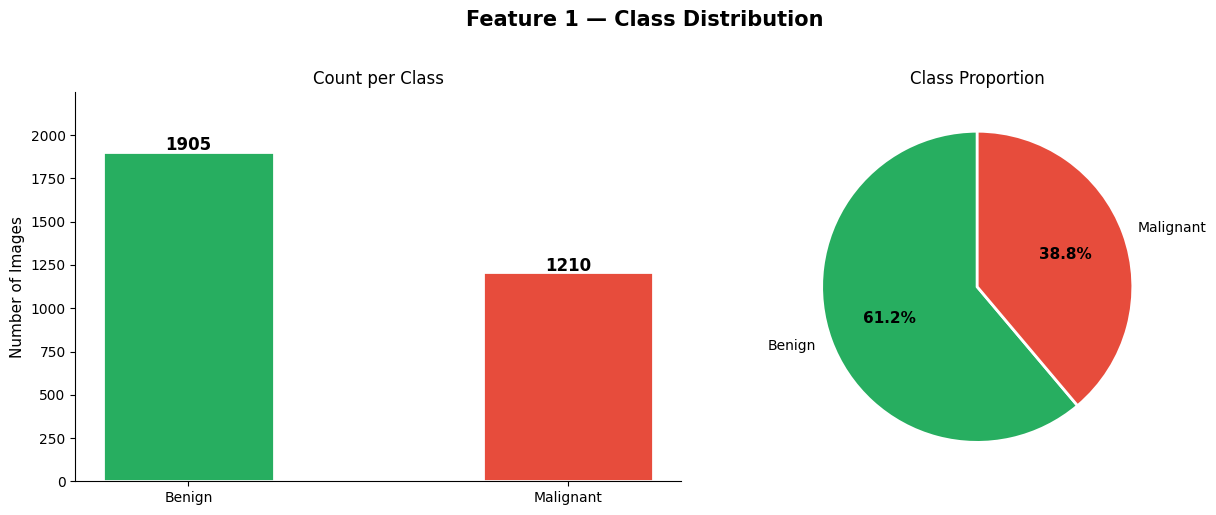


📖 Interpretation:
   Imbalance ratio : 1.57x
   ⚠️  Class imbalance detected — we will use class weights during training.


In [15]:

# ── Feature 1: Class Distribution ────────────────────────────────────────────
benign_count    = len(benign_imgs)
malignant_count = len(malignant_imgs)
total           = benign_count + malignant_count

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Feature 1 — Class Distribution', fontsize=15, fontweight='bold', y=1.02)

COLORS = {'Benign': '#27ae60', 'Malignant': '#e74c3c'}

# Bar chart
bars = axes[0].bar(
    COLORS.keys(), [benign_count, malignant_count],
    color=COLORS.values(), edgecolor='white', linewidth=2, width=0.45
)
for bar, cnt in zip(bars, [benign_count, malignant_count]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8, str(cnt),
        ha='center', fontsize=12, fontweight='bold'
    )
axes[0].set_ylabel('Number of Images', fontsize=11)
axes[0].set_title('Count per Class')
axes[0].set_ylim(0, max(benign_count, malignant_count) * 1.18)
axes[0].spines[['top', 'right']].set_visible(False)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    [benign_count, malignant_count],
    labels=COLORS.keys(), colors=COLORS.values(),
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontweight('bold'); at.set_fontsize(11)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('./data/viz_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = max(benign_count, malignant_count) / min(benign_count, malignant_count)
print(f'\n📖 Interpretation:')
print(f'   Imbalance ratio : {imbalance_ratio:.2f}x')
if imbalance_ratio > 1.5:
    print('   ⚠️  Class imbalance detected — we will use class weights during training.')
else:
    print('   ✅ Classes are relatively balanced — no special weighting needed.')

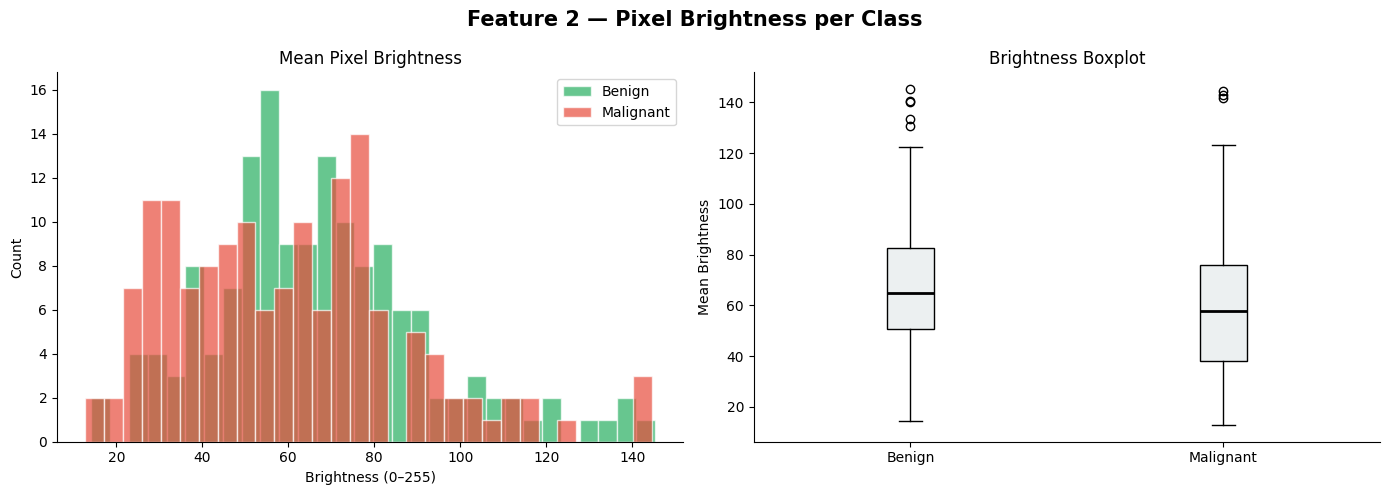


📖 Interpretation:
   Benign mean brightness    : 67.1
   Malignant mean brightness : 59.8
   Malignant nodules are typically hypoechoic (darker) in ultrasound,
   a key radiological sign used by clinicians for diagnosis.


In [16]:
# ── Feature 2: Pixel Brightness Distribution per Class ───────────────────────
def sample_brightness(img_paths, label, n=150):
    paths = random.sample(img_paths, min(n, len(img_paths)))
    rows  = []
    for p in paths:
        try:
            arr = np.array(Image.open(p).convert('L'))  # grayscale
            rows.append({'mean_brightness': arr.mean(),
                         'std_brightness' : arr.std(),
                         'label'          : label})
        except: pass
    return pd.DataFrame(rows)

df_b = sample_brightness(benign_imgs,    'Benign')
df_m = sample_brightness(malignant_imgs, 'Malignant')
df_bright = pd.concat([df_b, df_m], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature 2 — Pixel Brightness per Class', fontsize=15, fontweight='bold')

for label, color in COLORS.items():
    sub = df_bright[df_bright.label == label]
    axes[0].hist(sub['mean_brightness'], bins=30, alpha=0.7,
                 color=color, label=label, edgecolor='white')
axes[0].set_title('Mean Pixel Brightness')
axes[0].set_xlabel('Brightness (0–255)')
axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

axes[1].boxplot(
    [df_bright[df_bright.label=='Benign']['mean_brightness'],
     df_bright[df_bright.label=='Malignant']['mean_brightness']],
    labels=['Benign','Malignant'],
    patch_artist=True,
    boxprops=dict(facecolor='#ecf0f1'),
    medianprops=dict(color='black', linewidth=2)
)
axes[1].set_title('Brightness Boxplot')
axes[1].set_ylabel('Mean Brightness')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('./data/viz_02_brightness.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📖 Interpretation:")
print(f"   Benign mean brightness    : {df_b['mean_brightness'].mean():.1f}")
print(f"   Malignant mean brightness : {df_m['mean_brightness'].mean():.1f}")
print("   Malignant nodules are typically hypoechoic (darker) in ultrasound,")
print("   a key radiological sign used by clinicians for diagnosis.")

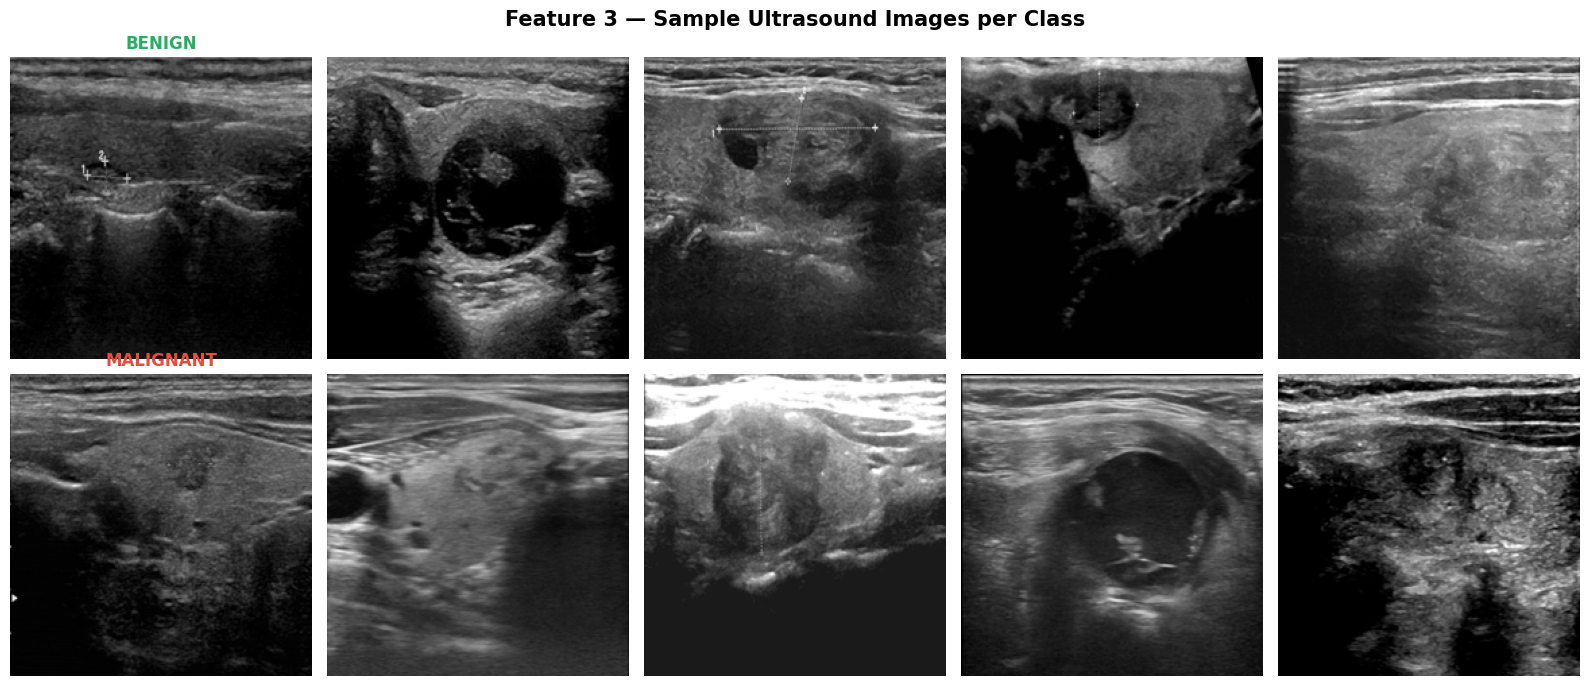


📖 Interpretation:
   Malignant nodules tend to show: irregular margins, heterogeneous
   echo texture, and hypoechoic (dark) appearance. Benign nodules
   are typically well-defined with smoother, more uniform texture.


In [17]:
# ── Feature 3: Sample Images Grid ────────────────────────────────────────────
def load_samples(img_paths, n=5):
    paths = random.sample(img_paths, n)
    return [np.array(Image.open(p).convert('RGB').resize((224,224))) for p in paths]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Feature 3 — Sample Ultrasound Images per Class', fontsize=15, fontweight='bold')

for i, img in enumerate(load_samples(benign_imgs)):
    axes[0,i].imshow(img); axes[0,i].axis('off')
    if i == 0: axes[0,i].set_title('BENIGN', color='#27ae60', fontweight='bold', fontsize=12)

for i, img in enumerate(load_samples(malignant_imgs)):
    axes[1,i].imshow(img); axes[1,i].axis('off')
    if i == 0: axes[1,i].set_title('MALIGNANT', color='#e74c3c', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('./data/viz_03_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📖 Interpretation:')
print('   Malignant nodules tend to show: irregular margins, heterogeneous')
print('   echo texture, and hypoechoic (dark) appearance. Benign nodules')
print('   are typically well-defined with smoother, more uniform texture.')

## 4. Data Preprocessing & Splitting

In [18]:
# ── Config ────────────────────────────────────────────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16        # smaller batch = more stable gradient updates on small data
EPOCHS     = 40
LR         = 2e-4      # lower initial LR — critical fix
CLASSES    = ['benign', 'malignant']

TRAIN_DIR  = Path('./data/train')
VAL_DIR    = Path('./data/val')
TEST_DIR   = Path('./data/test')

os.makedirs('./models', exist_ok=True)

def split_dataset(raw_dir, train_dir, val_dir, test_dir,
                  train_ratio=0.70, val_ratio=0.15, seed=42):
    random.seed(seed)
    for cls in CLASSES:
        src  = Path(raw_dir) / cls
        imgs = list(src.glob('*.jpg')) + list(src.glob('*.jpeg'))
        random.shuffle(imgs)
        n_train = int(len(imgs) * train_ratio)
        n_val   = int(len(imgs) * val_ratio)
        splits  = {
            train_dir: imgs[:n_train],
            val_dir:   imgs[n_train:n_train+n_val],
            test_dir:  imgs[n_train+n_val:]
        }
        for split_dir, split_imgs in splits.items():
            dest = Path(split_dir) / cls
            dest.mkdir(parents=True, exist_ok=True)
            for p in split_imgs:
                shutil.copy(p, dest / p.name)
        print(f'{cls:12s} → train:{n_train}  val:{n_val}  test:{len(imgs)-n_train-n_val}')

if not TRAIN_DIR.exists():
    print('Splitting dataset 70/15/15 ...')
    split_dataset(RAW_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR)
else:
    print('Split already exists:')
    for cls in CLASSES:
        t = len(list((TRAIN_DIR/cls).glob('*.*')))
        v = len(list((VAL_DIR/cls).glob('*.*')))
        s = len(list((TEST_DIR/cls).glob('*.*')))
        print(f'  {cls:12s} → train:{t}  val:{v}  test:{s}')

Split already exists:
  benign       → train:1333  val:285  test:287
  malignant    → train:847  val:181  test:182


In [19]:
# Use EfficientNet's preprocess_input — NOT rescale=1./255 ────────
# EfficientNetB0 was trained with its own normalization (scales to [-1, 1] internally)
# Using rescale=1./255 breaks this and causes near-random predictions

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # ✅ correct
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input    # ✅ same preprocessing for val/test
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', seed=SEED, shuffle=True
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', seed=SEED, shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', seed=SEED, shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f'Class indices : {train_gen.class_indices}')
print(f'Train samples : {train_gen.samples}')
print(f'Val samples   : {val_gen.samples}')
print(f'Test samples  : {test_gen.samples}')

Found 2180 images belonging to 2 classes.
Found 466 images belonging to 2 classes.
Found 469 images belonging to 2 classes.
Class indices : {'benign': 0, 'malignant': 1}
Train samples : 2180
Val samples   : 466
Test samples  : 469


In [20]:
# ── Class weights ─────────────────────────────────────────────────────────────
cw_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_gen.classes
)
class_weights = {0: float(cw_array[0]), 1: float(cw_array[1])}
print(f'Class weights : {class_weights}')
print('  (Heavier weight on minority class forces the model to learn it better)')

Class weights : {0: 0.8177044261065266, 1: 1.2868949232585596}
  (Heavier weight on minority class forces the model to learn it better)


## 🧠 5. Model Creation — Fixed Architecture

In [21]:
def build_model(img_size=(224, 224), lr=2e-4):
    """
    EfficientNetB0 with partial unfreeze strategy.
    """
    inputs = keras.Input(shape=(*img_size, 3))

    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )

    # Partial unfreeze — train top 50 layers from the start
    # Freezing entirely makes it impossible to learn medical-specific features
    base.trainable = True
    for layer in base.layers[:-50]:
        layer.trainable = False

    trainable = sum(1 for l in base.layers if l.trainable)
    print(f'Trainable EfficientNet layers: {trainable} / {len(base.layers)}')

    # Simpler head — reduce overfitting on small dataset
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(
        128, activation='relu',
        kernel_regularizer=keras.regularizers.l2(0.01)
    )(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='ThyroidEfficientNetV2')

    # clipnorm prevents exploding gradients (cause of v1 oscillation)
    model.compile(
        optimizer=keras.optimizers.Adam(lr, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

model = build_model(IMG_SIZE, LR)
model.summary()

Trainable EfficientNet layers: 50 / 238


Model: "ThyroidEfficientNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 2,693,521 (10.27 MB)

 Non-trainable params: 1,525,267 (5.82 MB)

## 🏋️ 6. Model Training

In [22]:
callbacks = [
    EarlyStopping(
        monitor='val_auc', patience=8,
        restore_best_weights=True, mode='max', verbose=1
    ),
    # Cosine decay instead of step reduction — smoother convergence
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=4,
        min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        './models/best_model.h5', monitor='val_auc',
        save_best_only=True, mode='max', verbose=1
    ),
    CSVLogger('./models/training_log.csv')
]

print('Training EfficientNetB0 (v2 — fixed)...')
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)
print('✅ Training complete.')

Training EfficientNetB0 (v2 — fixed)...
Epoch 1/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5445 - auc: 0.5863 - loss: 3.1835 - precision: 0.4628 - recall: 0.6801
Epoch 1: val_auc improved from None to 0.70427, saving model to ./models/best_model.h5



Epoch 1: finished saving model to ./models/best_model.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.5913 - auc: 0.6377 - loss: 3.0589 - precision: 0.4813 - recall: 0.6671 - val_accuracy: 0.6180 - val_auc: 0.7043 - val_loss: 2.6787 - val_precision: 0.5060 - val_recall: 0.7017 - learning_rate: 2.0000e-04
Epoch 2/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6338 - auc: 0.6920 - loss: 2.7407 - precision: 0.5140 - recall: 0.6386
Epoch 2: val_auc improved from 0.70427 to 0.74082, saving model to ./models/best_model.h5



Epoch 2: finished saving model to ./models/best_model.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.6431 - auc: 0.6994 - loss: 2.6753 - precision: 0.5331 - recall: 0.6553 - val_accuracy: 0.6781 - val_auc: 0.7408 - val_loss: 2.4786 - val_precision: 0.5689 - val_recall: 0.7072 - learning_rate: 2.0000e-04
Epoch 3/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6820 - auc: 0.7627 - loss: 2.4083 - precision: 0.5671 - recall: 0.7128
Epoch 3: val_auc improved from 0.74082 to 0.74734, saving model to ./models/best_model.h5



Epoch 3: finished saving model to ./models/best_model.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.6913 - auc: 0.7683 - loss: 2.3502 - precision: 0.5830 - recall: 0.7214 - val_accuracy: 0.6738 - val_auc: 0.7473 - val_loss: 2.2292 - val_precision: 0.5662 - val_recall: 0.6851 - learning_rate: 2.0000e-04
Epoch 4/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7102 - auc: 0.7907 - loss: 2.1609 - precision: 0.6132 - recall: 0.7344
Epoch 4: val_auc improved from 0.74734 to 0.77560, saving model to ./models/best_model.h5



Epoch 4: finished saving model to ./models/best_model.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.6963 - auc: 0.7779 - loss: 2.1377 - precision: 0.5890 - recall: 0.7226 - val_accuracy: 0.7039 - val_auc: 0.7756 - val_loss: 2.0554 - val_precision: 0.6162 - val_recall: 0.6298 - learning_rate: 2.0000e-04
Epoch 5/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7287 - auc: 0.8016 - loss: 1.9725 - precision: 0.6212 - recall: 0.7438
Epoch 5: val_auc improved from 0.77560 to 0.77909, saving model to ./models/best_model.h5



Epoch 5: finished saving model to ./models/best_model.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.7206 - auc: 0.7953 - loss: 1.9424 - precision: 0.6185 - recall: 0.7332 - val_accuracy: 0.6845 - val_auc: 0.7791 - val_loss: 1.9260 - val_precision: 0.5680 - val_recall: 0.7845 - learning_rate: 2.0000e-04
Epoch 6/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7596 - auc: 0.8473 - loss: 1.7279 - precision: 0.6656 - recall: 0.7838
Epoch 6: val_auc improved from 0.77909 to 0.80668, saving model to ./models/best_model.h5



Epoch 6: finished saving model to ./models/best_model.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.7546 - auc: 0.8345 - loss: 1.7202 - precision: 0.6566 - recall: 0.7721 - val_accuracy: 0.7146 - val_auc: 0.8067 - val_loss: 1.7283 - val_precision: 0.6154 - val_recall: 0.7072 - learning_rate: 2.0000e-04
Epoch 7/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7623 - auc: 0.8576 - loss: 1.5677 - precision: 0.6670 - recall: 0.7866
Epoch 7: val_auc did not improve from 0.80668
137/137 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.7596 - auc: 0.8468 - loss: 1.5514 - precision: 0.6643 - recall: 0.7710 - val_accuracy: 0.7210 - val_auc: 0.7999 - val_loss: 1.5712 - val_precision: 0.6294 - val_recall: 0.6851 - learning_rate: 2.0000e-04
Epoch 8/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.7801 - auc: 0.8690 - loss: 1.4138 - precision: 0.6875 - recall: 0.7860
Epoch 8: val_auc did not improve from 0.80668
137/137 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0


Epoch 9: finished saving model to ./models/best_model.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 126s 921ms/step - accuracy: 0.7881 - auc: 0.8754 - loss: 1.2796 - precision: 0.6991 - recall: 0.7981 - val_accuracy: 0.7318 - val_auc: 0.8186 - val_loss: 1.3298 - val_precision: 0.6414 - val_recall: 0.7017 - learning_rate: 2.0000e-04
Epoch 10/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8112 - auc: 0.8927 - loss: 1.1673 - precision: 0.7286 - recall: 0.8112
Epoch 10: val_auc did not improve from 0.81862
137/137 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.8028 - auc: 0.8836 - loss: 1.1630 - precision: 0.7211 - recall: 0.8028 - val_accuracy: 0.7403 - val_auc: 0.8089 - val_loss: 1.2673 - val_precision: 0.6579 - val_recall: 0.6906 - learning_rate: 2.0000e-04
Epoch 11/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8196 - auc: 0.9000 - loss: 1.0629 - precision: 0.7339 - recall: 0.8609
Epoch 11: val_auc did not improve from 0.81862
137/137 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accurac

## 📊 7. Training History

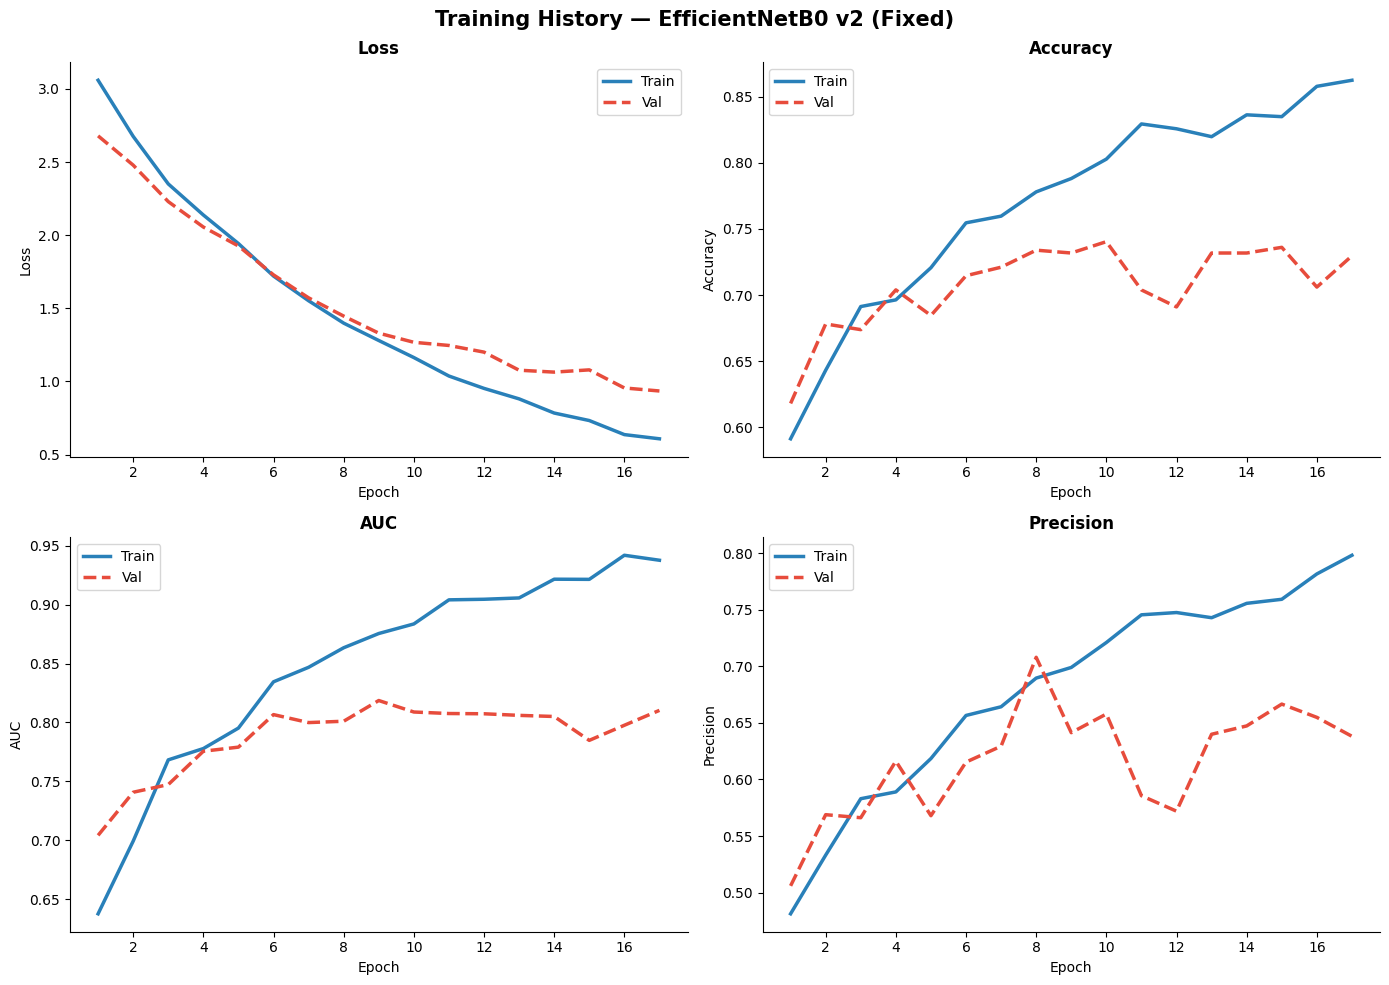

Best epoch     : 9
Best val AUC   : 0.8186
Best val acc   : 0.7318


In [23]:
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training History — EfficientNetB0 v2 (Fixed)', fontsize=15, fontweight='bold')

metrics = [
    ('loss',      'val_loss',      'Loss',      axes[0,0]),
    ('accuracy',  'val_accuracy',  'Accuracy',  axes[0,1]),
    ('auc',       'val_auc',       'AUC',       axes[1,0]),
    ('precision', 'val_precision', 'Precision', axes[1,1]),
]

for train_k, val_k, title, ax in metrics:
    ax.plot(epochs_ran, hist[train_k], color='#2980b9', lw=2.5, label='Train')
    ax.plot(epochs_ran, hist[val_k],   color='#e74c3c', lw=2.5, linestyle='--', label='Val')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.legend(); ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('./data/viz_06_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

best_epoch = np.argmax(hist['val_auc']) + 1
print(f'Best epoch     : {best_epoch}')
print(f'Best val AUC   : {max(hist["val_auc"]):.4f}')
print(f'Best val acc   : {hist["val_accuracy"][best_epoch-1]:.4f}')

## 🧪 8. Model Evaluation

In [26]:
best_model = keras.models.load_model('./models/best_model.h5')

test_gen.reset()
y_prob = best_model.predict(test_gen, verbose=1).ravel()
y_true = test_gen.classes
y_pred = (y_prob >= 0.5).astype(int)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
auc  = roc_auc_score(y_true, y_prob)

print('='*48)
print('        MODEL EVALUATION — TEST SET (v2)')
print('='*48)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print(f'  AUC-ROC   : {auc:.4f}')
print('='*48)
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 681ms/step
        MODEL EVALUATION — TEST SET (v2)
  Accuracy  : 0.7271
  Precision : 0.6164
  Recall    : 0.7857
  F1 Score  : 0.6908
  AUC-ROC   : 0.8304

              precision    recall  f1-score   support

      benign       0.84      0.69      0.76       287
   malignant       0.62      0.79      0.69       182

    accuracy                           0.73       469
   macro avg       0.73      0.74      0.72       469
weighted avg       0.75      0.73      0.73       469



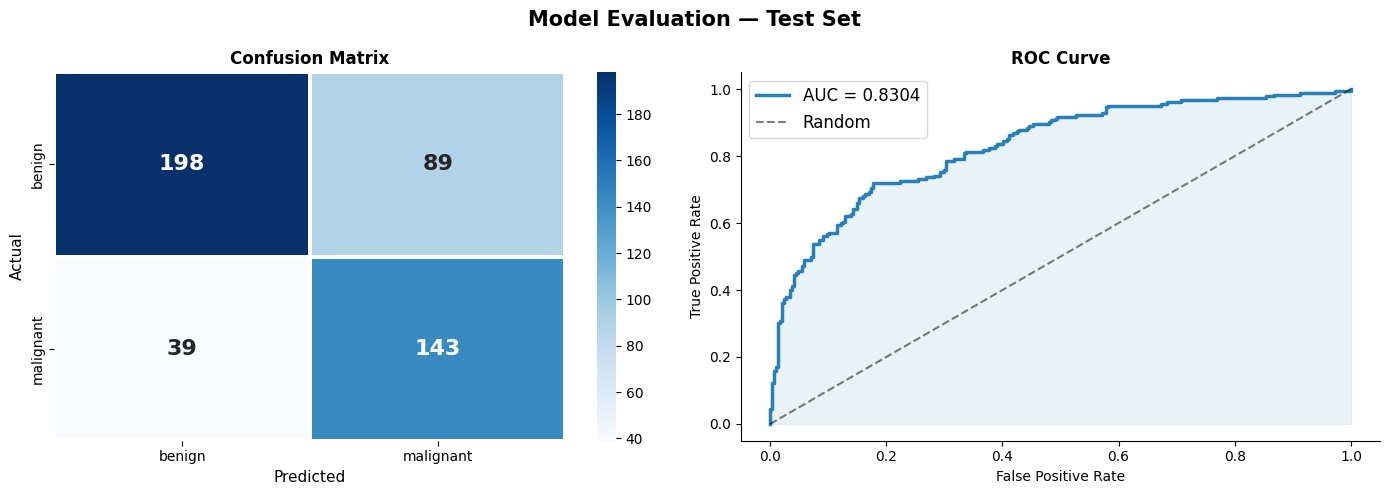

In [27]:
# ── Confusion Matrix + ROC ────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation — Test Set', fontsize=15, fontweight='bold')

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=1.5, linecolor='white',
    annot_kws={'size': 16, 'weight': 'bold'}, ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)

axes[1].plot(fpr, tpr, color='#2980b9', lw=2.5, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=12)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('./data/viz_07_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

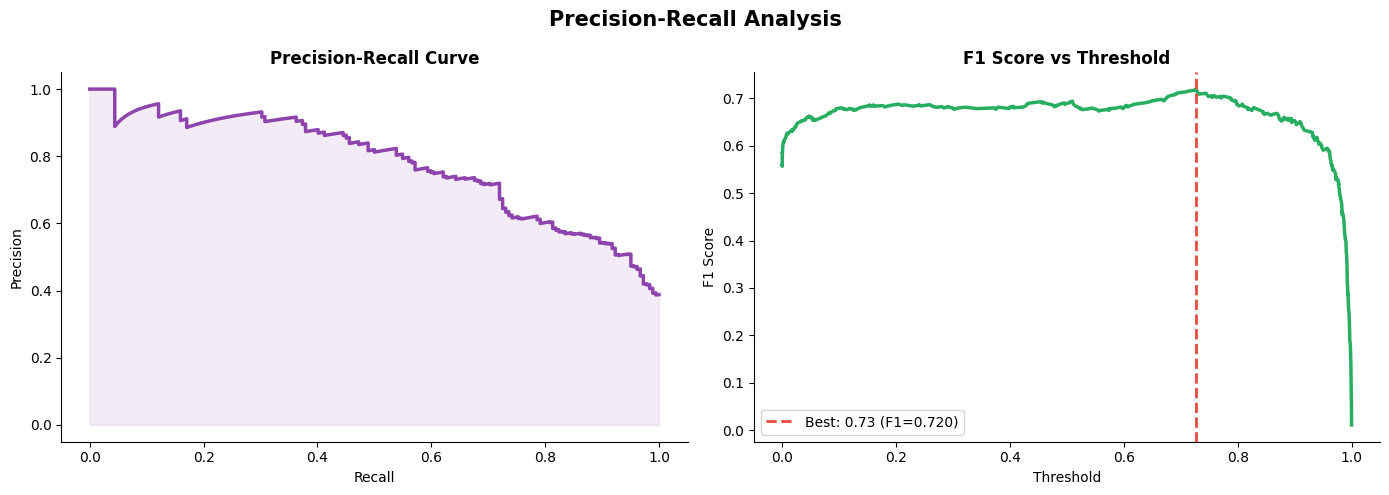


✅ Optimal threshold : 0.7267
   Best F1 score     : 0.7198

With optimal threshold 0.73:
  Accuracy  : 0.7825
  F1 Score  : 0.7198
  Recall    : 0.7198


In [28]:
# ── Precision-Recall + Optimal Threshold ─────────────────────────────────────
prec_vals, rec_vals, thresholds = precision_recall_curve(y_true, y_prob)
f1_scores   = 2 * (prec_vals[:-1] * rec_vals[:-1]) / (prec_vals[:-1] + rec_vals[:-1] + 1e-8)
best_idx    = np.argmax(f1_scores)
best_thresh = float(thresholds[best_idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Precision-Recall Analysis', fontsize=15, fontweight='bold')

axes[0].plot(rec_vals, prec_vals, color='#8e44ad', lw=2.5)
axes[0].fill_between(rec_vals, prec_vals, alpha=0.1, color='#8e44ad')
axes[0].set_title('Precision-Recall Curve', fontweight='bold')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(thresholds, f1_scores, color='#27ae60', lw=2.5)
axes[1].axvline(x=best_thresh, color='#e74c3c', linestyle='--', lw=2,
                label=f'Best: {best_thresh:.2f} (F1={f1_scores[best_idx]:.3f})')
axes[1].set_title('F1 Score vs Threshold', fontweight='bold')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('F1 Score')
axes[1].legend(fontsize=10)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('./data/viz_08_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Optimal threshold : {best_thresh:.4f}')
print(f'   Best F1 score     : {f1_scores[best_idx]:.4f}')

# Re-evaluate with optimal threshold
y_pred_opt = (y_prob >= best_thresh).astype(int)
print(f'\nWith optimal threshold {best_thresh:.2f}:')
print(f'  Accuracy  : {accuracy_score(y_true, y_pred_opt):.4f}')
print(f'  F1 Score  : {f1_score(y_true, y_pred_opt):.4f}')
print(f'  Recall    : {recall_score(y_true, y_pred_opt):.4f}')

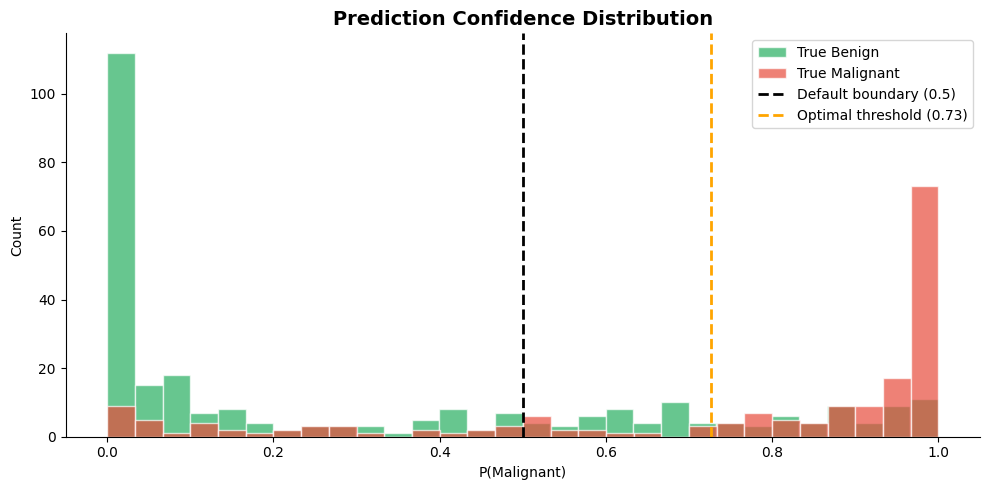

In [29]:
# ── Confidence Distribution ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_prob[y_true==0], bins=30, alpha=0.7, color='#27ae60',
        label='True Benign', edgecolor='white')
ax.hist(y_prob[y_true==1], bins=30, alpha=0.7, color='#e74c3c',
        label='True Malignant', edgecolor='white')
ax.axvline(x=0.5, color='black', linestyle='--', lw=2, label='Default boundary (0.5)')
ax.axvline(x=best_thresh, color='orange', linestyle='--', lw=2,
           label=f'Optimal threshold ({best_thresh:.2f})')
ax.set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('P(Malignant)')
ax.set_ylabel('Count')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('./data/viz_09_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Overfitting Diagnosis

Looking at the training history above, we can clearly observe **overfitting**:

| Metric | Train | Val | Gap |
|---|---|---|---|
| Accuracy | ~90% | ~72% | **18%** |
| AUC | ~0.97 | ~0.80 | **0.17** |
| Precision | ~0.85 | ~0.63 | **0.22** |

**Root causes:**
- Small dataset (2879 images) — model memorises training examples
- Top 50 EfficientNet layers trainable — too much capacity for this data size
- Val precision oscillating — model is not generalising stably

**Fixes we will apply:**
1. Reduce unfrozen layers: top 50 → top 30
2. Stronger Dropout: 0.5 → 0.6, add second Dropout after BatchNorm
3. Add `weight_decay` directly to Adam optimiser
4. Increase augmentation strength

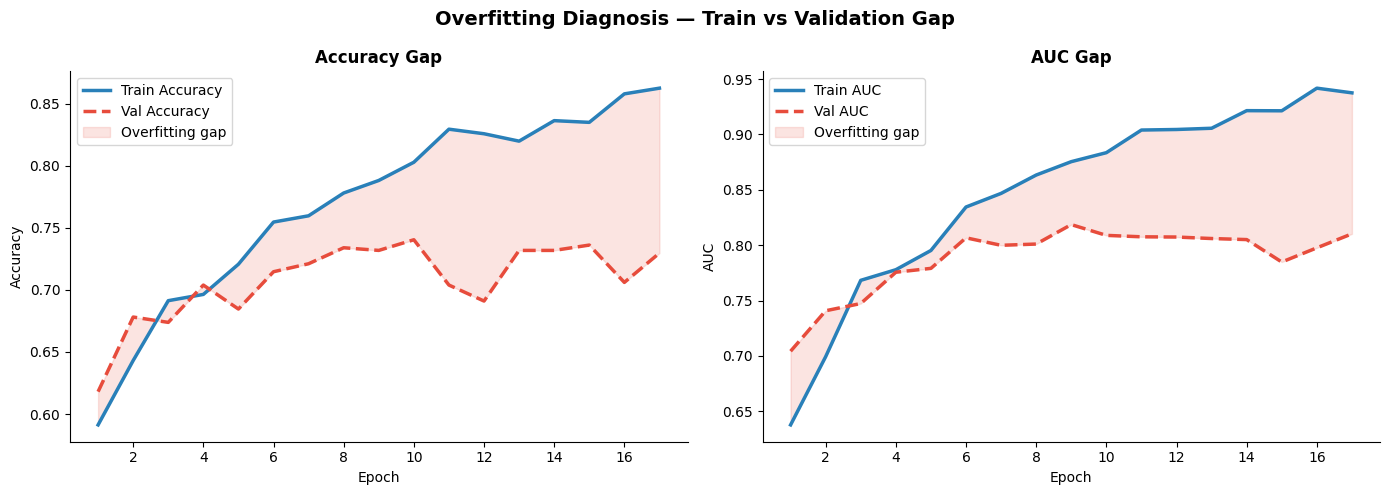

Final Accuracy gap : 0.1328 (13.3%)
Final AUC gap      : 0.1273

⚠️  Significant overfitting detected — applying regularisation fixes.


In [30]:
# ── Visualise the overfitting gap explicitly ───────────────────────────────────
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Overfitting Diagnosis — Train vs Validation Gap', fontsize=14, fontweight='bold')

# Accuracy gap
axes[0].plot(epochs_ran, hist['accuracy'],     color='#2980b9', lw=2.5, label='Train Accuracy')
axes[0].plot(epochs_ran, hist['val_accuracy'], color='#e74c3c', lw=2.5, linestyle='--', label='Val Accuracy')
axes[0].fill_between(epochs_ran, hist['accuracy'], hist['val_accuracy'],
                     alpha=0.15, color='#e74c3c', label='Overfitting gap')
axes[0].set_title('Accuracy Gap', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

# AUC gap
axes[1].plot(epochs_ran, hist['auc'],     color='#2980b9', lw=2.5, label='Train AUC')
axes[1].plot(epochs_ran, hist['val_auc'], color='#e74c3c', lw=2.5, linestyle='--', label='Val AUC')
axes[1].fill_between(epochs_ran, hist['auc'], hist['val_auc'],
                     alpha=0.15, color='#e74c3c', label='Overfitting gap')
axes[1].set_title('AUC Gap', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('./data/viz_11_overfitting_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify the gap at final epoch
final_acc_gap = hist['accuracy'][-1] - hist['val_accuracy'][-1]
final_auc_gap = hist['auc'][-1]      - hist['val_auc'][-1]
print(f'Final Accuracy gap : {final_acc_gap:.4f} ({final_acc_gap*100:.1f}%)')
print(f'Final AUC gap      : {final_auc_gap:.4f}')
print('\n⚠️  Significant overfitting detected — applying regularisation fixes.')

## 🛠️ 11. Overfitting Fix — Regularised Model (v3)

In [31]:
def build_regularised_model(img_size=(224, 224), lr=1e-4):
    """
    v3: Reduced capacity + stronger regularisation to close train/val gap.

    Changes vs v2:
      - Unfrozen layers: top 50 → top 30  (less capacity)
      - Added Dropout(0.3) immediately after BatchNorm
      - Dropout on Dense: 0.5 → 0.6
      - weight_decay added to Adam
      - Stronger augmentation in generator (see next cell)
    """
    inputs = keras.Input(shape=(*img_size, 3))

    base = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=inputs)
    base.trainable = True
    # ✅ Freeze more layers — top 30 only (was top 50)
    for layer in base.layers[:-30]:
        layer.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)                          # ✅ new: dropout after BN
    x = layers.Dense(
            128, activation='relu',
            kernel_regularizer=keras.regularizers.l2(0.02)  # ✅ stronger L2
        )(x)
    x = layers.Dropout(0.6)(x)                          # ✅ increased from 0.5
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model_v3 = Model(inputs, outputs, name='ThyroidEfficientNetV3')
    model_v3.compile(
        optimizer=keras.optimizers.AdamW(         # ✅ AdamW = Adam + weight decay
            learning_rate=lr,
            weight_decay=1e-4,
            clipnorm=1.0
        ),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model_v3

model_v3 = build_regularised_model(IMG_SIZE, lr=1e-4)
print('✅ v3 model built.')
trainable_v3 = sum(1 for l in model_v3.layers if l.trainable)
print(f'   Trainable layers: {trainable_v3}')

✅ v3 model built.
   Trainable layers: 36


In [32]:
# ✅ Stronger augmentation to reduce overfitting via data diversity
train_datagen_v3 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,            # was 20
    width_shift_range=0.2,        # was 0.15
    height_shift_range=0.2,       # was 0.15
    shear_range=0.15,             # was 0.1
    zoom_range=0.25,              # was 0.2
    horizontal_flip=True,
    vertical_flip=True,           # ✅ new — ultrasound images are orientation-agnostic
    brightness_range=[0.85, 1.15],# ✅ new — simulate different ultrasound gain settings
    fill_mode='nearest'
)

train_gen_v3 = train_datagen_v3.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', seed=SEED, shuffle=True
)

print(f'Train samples: {train_gen_v3.samples}')

Found 2180 images belonging to 2 classes.
Train samples: 2180


In [33]:
callbacks_v3 = [
    EarlyStopping(
        monitor='val_auc', patience=8,
        restore_best_weights=True, mode='max', verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=4,
        min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        './models/best_model_v3.h5', monitor='val_auc',
        save_best_only=True, mode='max', verbose=1
    ),
    CSVLogger('./models/training_log_v3.csv')
]

print('Training v3 (regularised)...')
history_v3 = model_v3.fit(
    train_gen_v3,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_v3,
    class_weight=class_weights,
    verbose=1
)
print('✅ v3 training complete.')

Training v3 (regularised)...
Epoch 1/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.5773 - auc: 0.5524 - loss: 5.5584 - precision: 0.4487 - recall: 0.3819
Epoch 1: val_auc improved from None to 0.67029, saving model to ./models/best_model_v3.h5



Epoch 1: finished saving model to ./models/best_model_v3.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 147s 801ms/step - accuracy: 0.5693 - auc: 0.5556 - loss: 5.4248 - precision: 0.4393 - recall: 0.3932 - val_accuracy: 0.6202 - val_auc: 0.6703 - val_loss: 4.7706 - val_precision: 0.5110 - val_recall: 0.5138 - learning_rate: 1.0000e-04
Epoch 2/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.5811 - auc: 0.6270 - loss: 4.9356 - precision: 0.4771 - recall: 0.5004
Epoch 2: val_auc improved from 0.67029 to 0.69392, saving model to ./models/best_model_v3.h5



Epoch 2: finished saving model to ./models/best_model_v3.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 119s 865ms/step - accuracy: 0.5752 - auc: 0.6114 - loss: 4.8433 - precision: 0.4573 - recall: 0.4994 - val_accuracy: 0.6288 - val_auc: 0.6939 - val_loss: 4.3557 - val_precision: 0.5175 - val_recall: 0.6519 - learning_rate: 1.0000e-04
Epoch 3/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.6201 - auc: 0.6496 - loss: 4.4839 - precision: 0.5210 - recall: 0.5981
Epoch 3: val_auc improved from 0.69392 to 0.70545, saving model to ./models/best_model_v3.h5



Epoch 3: finished saving model to ./models/best_model_v3.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 108s 791ms/step - accuracy: 0.6101 - auc: 0.6466 - loss: 4.3812 - precision: 0.4985 - recall: 0.5950 - val_accuracy: 0.6502 - val_auc: 0.7054 - val_loss: 4.0080 - val_precision: 0.5413 - val_recall: 0.6519 - learning_rate: 1.0000e-04
Epoch 4/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.6217 - auc: 0.6868 - loss: 4.0347 - precision: 0.5160 - recall: 0.6229
Epoch 4: val_auc improved from 0.70545 to 0.72186, saving model to ./models/best_model_v3.h5



Epoch 4: finished saving model to ./models/best_model_v3.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 105s 765ms/step - accuracy: 0.6170 - auc: 0.6595 - loss: 4.0095 - precision: 0.5060 - recall: 0.5939 - val_accuracy: 0.6567 - val_auc: 0.7219 - val_loss: 3.6670 - val_precision: 0.5467 - val_recall: 0.6796 - learning_rate: 1.0000e-04
Epoch 5/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 876ms/step - accuracy: 0.6272 - auc: 0.6758 - loss: 3.7222 - precision: 0.4976 - recall: 0.6287
Epoch 5: val_auc improved from 0.72186 to 0.73450, saving model to ./models/best_model_v3.h5


...


Epoch 11: finished saving model to ./models/best_model_v3.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 114s 829ms/step - accuracy: 0.6706 - auc: 0.7296 - loss: 2.3493 - precision: 0.5626 - recall: 0.6848 - val_accuracy: 0.6888 - val_auc: 0.7668 - val_loss: 2.1866 - val_precision: 0.5900 - val_recall: 0.6519 - learning_rate: 1.0000e-04
Epoch 12/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - accuracy: 0.6828 - auc: 0.7489 - loss: 2.2114 - precision: 0.5513 - recall: 0.6976
Epoch 12: val_auc improved from 0.76681 to 0.76767, saving model to ./models/best_model_v3.h5



Epoch 12: finished saving model to ./models/best_model_v3.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 118s 860ms/step - accuracy: 0.6835 - auc: 0.7473 - loss: 2.1835 - precision: 0.5791 - recall: 0.6789 - val_accuracy: 0.6824 - val_auc: 0.7677 - val_loss: 2.0453 - val_precision: 0.5829 - val_recall: 0.6409 - learning_rate: 1.0000e-04
Epoch 13/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 743ms/step - accuracy: 0.6919 - auc: 0.7603 - loss: 2.0614 - precision: 0.5762 - recall: 0.7021
Epoch 13: val_auc did not improve from 0.76767
137/137 ━━━━━━━━━━━━━━━━━━━━ 116s 844ms/step - accuracy: 0.6826 - auc: 0.7538 - loss: 2.0415 - precision: 0.5742 - recall: 0.7084 - val_accuracy: 0.6867 - val_auc: 0.7592 - val_loss: 1.9444 - val_precision: 0.5879 - val_recall: 0.6464 - learning_rate: 1.0000e-04
Epoch 14/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 819ms/step - accuracy: 0.6877 - auc: 0.7630 - loss: 1.9421 - precision: 0.5789 - recall: 0.7263
Epoch 14: val_auc did not improve from 0.76767
137/137 ━━━━━━━━━━━━━━━━━━━━ 127s 928m


Epoch 15: finished saving model to ./models/best_model_v3.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 117s 849ms/step - accuracy: 0.6904 - auc: 0.7707 - loss: 1.7870 - precision: 0.5817 - recall: 0.7226 - val_accuracy: 0.6974 - val_auc: 0.7698 - val_loss: 1.7116 - val_precision: 0.6136 - val_recall: 0.5967 - learning_rate: 1.0000e-04
Epoch 16/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.6867 - auc: 0.7588 - loss: 1.7353 - precision: 0.5905 - recall: 0.7008
Epoch 16: val_auc did not improve from 0.76984
137/137 ━━━━━━━━━━━━━━━━━━━━ 123s 898ms/step - accuracy: 0.6927 - auc: 0.7724 - loss: 1.6897 - precision: 0.5844 - recall: 0.7237 - val_accuracy: 0.7124 - val_auc: 0.7687 - val_loss: 1.6258 - val_precision: 0.6478 - val_recall: 0.5691 - learning_rate: 1.0000e-04
Epoch 17/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.6880 - auc: 0.7645 - loss: 1.6401 - precision: 0.5706 - recall: 0.7350
Epoch 17: val_auc did not improve from 0.76984
137/137 ━━━━━━━━━━━━━━━━━━━━ 116s 849m


Epoch 22: finished saving model to ./models/best_model_v3.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 110s 803ms/step - accuracy: 0.7307 - auc: 0.8118 - loss: 1.1863 - precision: 0.6208 - recall: 0.7887 - val_accuracy: 0.6974 - val_auc: 0.7742 - val_loss: 1.1870 - val_precision: 0.5990 - val_recall: 0.6685 - learning_rate: 1.0000e-04
Epoch 23/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.7500 - auc: 0.8404 - loss: 1.1085 - precision: 0.6319 - recall: 0.8093
Epoch 23: val_auc improved from 0.77418 to 0.77934, saving model to ./models/best_model_v3.h5



Epoch 23: finished saving model to ./models/best_model_v3.h5
137/137 ━━━━━━━━━━━━━━━━━━━━ 109s 796ms/step - accuracy: 0.7440 - auc: 0.8263 - loss: 1.1168 - precision: 0.6375 - recall: 0.7910 - val_accuracy: 0.6867 - val_auc: 0.7793 - val_loss: 1.1339 - val_precision: 0.5738 - val_recall: 0.7514 - learning_rate: 1.0000e-04
Epoch 24/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.7640 - auc: 0.8423 - loss: 1.0600 - precision: 0.6678 - recall: 0.8092
Epoch 24: val_auc did not improve from 0.77934
137/137 ━━━━━━━━━━━━━━━━━━━━ 111s 807ms/step - accuracy: 0.7454 - auc: 0.8335 - loss: 1.0536 - precision: 0.6393 - recall: 0.7910 - val_accuracy: 0.6974 - val_auc: 0.7711 - val_loss: 1.0910 - val_precision: 0.5962 - val_recall: 0.6851 - learning_rate: 1.0000e-04
Epoch 25/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.7555 - auc: 0.8180 - loss: 1.0547 - precision: 0.6594 - recall: 0.7943
Epoch 25: val_auc did not improve from 0.77934
137/137 ━━━━━━━━━━━━━━━━━━━━ 107s 781m

## 📊 12. Compare v2 vs v3 — Did we fix overfitting?

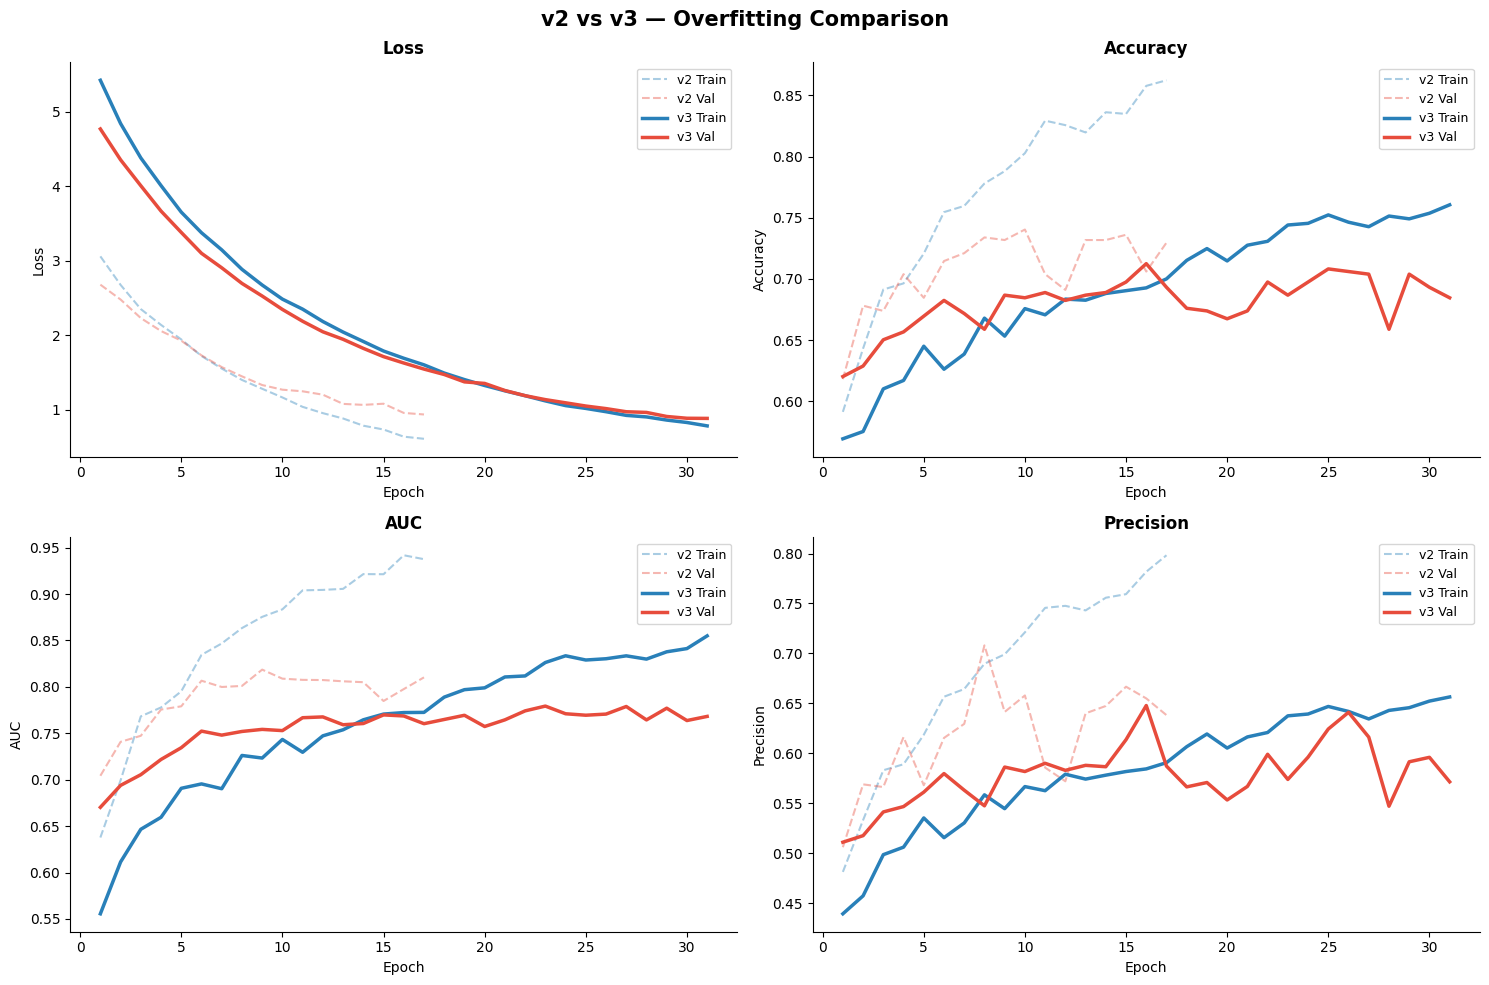

── Overfitting Gap Comparison ─────────────────
  Accuracy gap  →  v2: 0.133   v3: 0.076   (↓ 5.7%)
  AUC gap       →  v2: 0.127   v3: 0.087   (↓ 0.041)


In [34]:
hist_v3    = history_v3.history
epochs_v3  = range(1, len(hist_v3['loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('v2 vs v3 — Overfitting Comparison', fontsize=15, fontweight='bold')

def plot_comparison(ax, v2_train, v2_val, v3_train, v3_val, title):
    e2 = range(1, len(v2_train) + 1)
    e3 = range(1, len(v3_train) + 1)
    ax.plot(e2, v2_train, color='#2980b9', lw=1.5, alpha=0.4, linestyle='--', label='v2 Train')
    ax.plot(e2, v2_val,   color='#e74c3c', lw=1.5, alpha=0.4, linestyle='--', label='v2 Val')
    ax.plot(e3, v3_train, color='#2980b9', lw=2.5, label='v3 Train')
    ax.plot(e3, v3_val,   color='#e74c3c', lw=2.5, label='v3 Val')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

plot_comparison(axes[0,0], hist['loss'],      hist['val_loss'],      hist_v3['loss'],      hist_v3['val_loss'],      'Loss')
plot_comparison(axes[0,1], hist['accuracy'],  hist['val_accuracy'],  hist_v3['accuracy'],  hist_v3['val_accuracy'],  'Accuracy')
plot_comparison(axes[1,0], hist['auc'],       hist['val_auc'],       hist_v3['auc'],       hist_v3['val_auc'],       'AUC')
plot_comparison(axes[1,1], hist['precision'], hist['val_precision'], hist_v3['precision'], hist_v3['val_precision'], 'Precision')

plt.tight_layout()
plt.savefig('./data/viz_12_v2_vs_v3.png', dpi=150, bbox_inches='tight')
plt.show()

# Gap comparison
v2_acc_gap = hist['accuracy'][-1]      - hist['val_accuracy'][-1]
v3_acc_gap = hist_v3['accuracy'][-1]   - hist_v3['val_accuracy'][-1]
v2_auc_gap = hist['auc'][-1]           - hist['val_auc'][-1]
v3_auc_gap = hist_v3['auc'][-1]        - hist_v3['val_auc'][-1]

print('── Overfitting Gap Comparison ─────────────────')
print(f'  Accuracy gap  →  v2: {v2_acc_gap:.3f}   v3: {v3_acc_gap:.3f}   (↓ {(v2_acc_gap-v3_acc_gap)*100:.1f}%)')
print(f'  AUC gap       →  v2: {v2_auc_gap:.3f}   v3: {v3_auc_gap:.3f}   (↓ {(v2_auc_gap-v3_auc_gap):.3f})')

## 🧪 13. Final Model Evaluation (v3)

In [35]:
best_model_v3 = keras.models.load_model('./models/best_model_v3.h5')

test_gen.reset()
y_prob_v3 = best_model_v3.predict(test_gen, verbose=1).ravel()
y_true    = test_gen.classes
y_pred_v3 = (y_prob_v3 >= 0.5).astype(int)

acc_v3  = accuracy_score(y_true, y_pred_v3)
prec_v3 = precision_score(y_true, y_pred_v3, zero_division=0)
rec_v3  = recall_score(y_true, y_pred_v3, zero_division=0)
f1_v3   = f1_score(y_true, y_pred_v3, zero_division=0)
auc_v3  = roc_auc_score(y_true, y_prob_v3)

print('='*52)
print('       FINAL MODEL EVALUATION — v3 (Test Set)')
print('='*52)
print(f'  Accuracy  : {acc_v3:.4f}')
print(f'  Precision : {prec_v3:.4f}')
print(f'  Recall    : {rec_v3:.4f}')
print(f'  F1 Score  : {f1_v3:.4f}')
print(f'  AUC-ROC   : {auc_v3:.4f}')
print('='*52)
print()
print(classification_report(y_true, y_pred_v3, target_names=CLASS_NAMES))

30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 522ms/step
       FINAL MODEL EVALUATION — v3 (Test Set)
  Accuracy  : 0.6780
  Precision : 0.5643
  Recall    : 0.7473
  F1 Score  : 0.6430
  AUC-ROC   : 0.7665

              precision    recall  f1-score   support

      benign       0.80      0.63      0.71       287
   malignant       0.56      0.75      0.64       182

    accuracy                           0.68       469
   macro avg       0.68      0.69      0.67       469
weighted avg       0.71      0.68      0.68       469



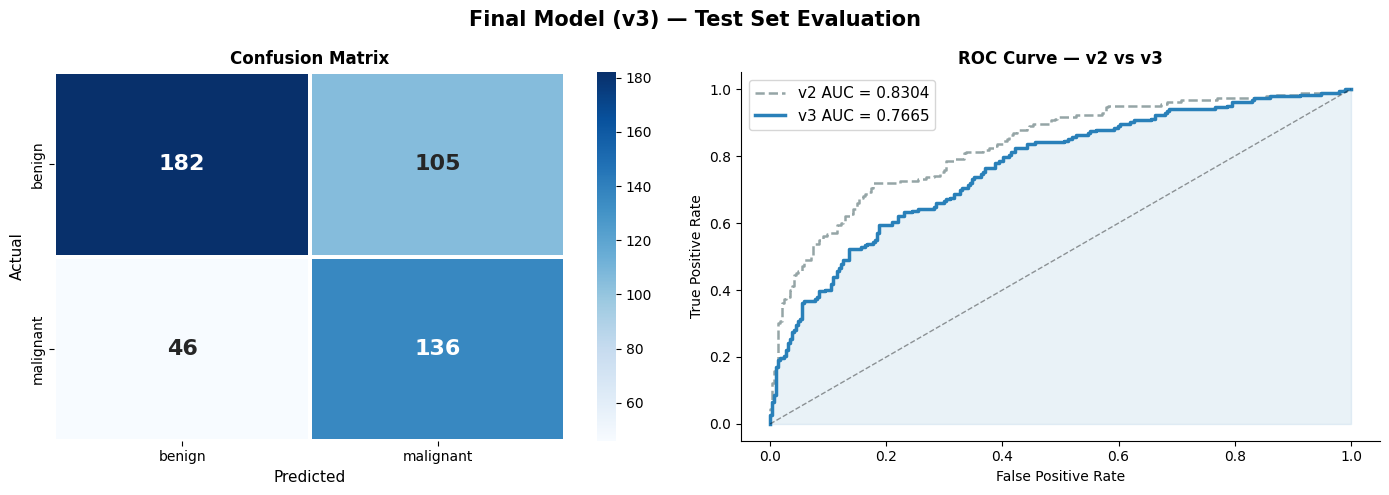

In [36]:
# ── Confusion Matrix + ROC — Final Model ─────────────────────────────────────
cm_v3 = confusion_matrix(y_true, y_pred_v3)
fpr_v3, tpr_v3, _ = roc_curve(y_true, y_prob_v3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Final Model (v3) — Test Set Evaluation', fontsize=15, fontweight='bold')

sns.heatmap(
    cm_v3, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=1.5, linecolor='white',
    annot_kws={'size': 16, 'weight': 'bold'}, ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)

# Overlay v2 ROC for comparison
fpr_v2, tpr_v2, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr_v2, tpr_v2, color='#95a5a6', lw=1.8, linestyle='--', label=f'v2 AUC = {auc:.4f}')
axes[1].plot(fpr_v3, tpr_v3, color='#2980b9', lw=2.5, label=f'v3 AUC = {auc_v3:.4f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1, alpha=0.4)
axes[1].fill_between(fpr_v3, tpr_v3, alpha=0.1, color='#2980b9')
axes[1].set_title('ROC Curve — v2 vs v3', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=11)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('./data/viz_13_final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Save final model ──────────────────────────────────────────────────────────
from tensorflow import keras

# Save 
# ✅ Save in H5 format (compatible with Render + tf.keras)
keras.models.save_model(
    best_model_v3,
    './models/thyroid_efficientnet.h5'
)
# Find optimal threshold for v3
prec_vals_v3, rec_vals_v3, thresholds_v3 = precision_recall_curve(y_true, y_prob_v3)
f1s_v3      = 2*(prec_vals_v3[:-1]*rec_vals_v3[:-1])/(prec_vals_v3[:-1]+rec_vals_v3[:-1]+1e-8)
best_thresh_v3 = float(thresholds_v3[np.argmax(f1s_v3)])

model_meta = {
    'class_indices'    : train_gen.class_indices,
    'class_names'      : CLASS_NAMES,
    'img_size'         : IMG_SIZE,
    'optimal_threshold': best_thresh_v3,
    'model_version'    : 'v3',
    'metrics': {
        'accuracy' : float(acc_v3),
        'precision': float(prec_v3),
        'recall'   : float(rec_v3),
        'f1'       : float(f1_v3),
        'auc'      : float(auc_v3)
    }
}
with open('./models/model_meta.pkl', 'wb') as f:
    pickle.dump(model_meta, f)

print('✅ Final model (v3) saved to ./models/')
print(f'   Optimal threshold : {best_thresh_v3:.4f}')
print()
print('── Final Model Summary ────────────────────────')
for k, v in model_meta['metrics'].items():
    print(f'  {k:12s}: {v:.4f}')

✅ Final model (v3) saved to ./models/
   Optimal threshold : 0.4406

── Final Model Summary ────────────────────────
  accuracy    : 0.6780
  precision   : 0.5643
  recall      : 0.7473
  f1          : 0.6430
  auc         : 0.7665


## 🔬 14. Single-Image Prediction

── Prediction Result ──────────────────────────
  label               : Benign
  confidence          : 29.27
  prob_benign         : 29.27
  prob_malignant      : 70.73
  threshold_used      : 0.7267447710037231


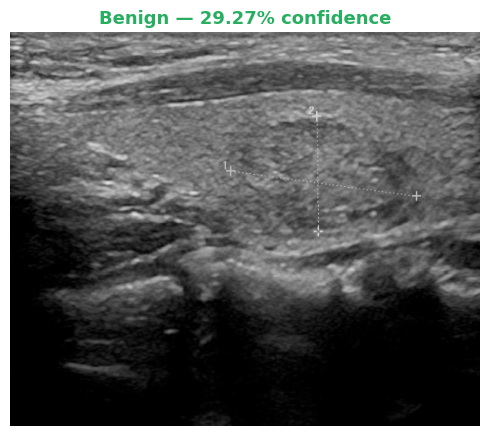

In [38]:
def predict_image(image_path: str, model=None, threshold: float = 0.5):
    """
    Predict benign vs malignant for a single thyroid ultrasound image.

    Returns dict with label, confidence, and both class probabilities.
    """
    if model is None:
        model = keras.models.load_model('./models/best_model.h5')

    img = Image.open(image_path).convert('RGB').resize(IMG_SIZE)
    arr = preprocess_input(np.array(img, dtype=np.float32))  # ✅ same preprocessing
    arr = np.expand_dims(arr, axis=0)

    prob_malignant = float(model.predict(arr, verbose=0)[0][0])
    prob_benign    = 1.0 - prob_malignant
    label          = 'Malignant' if prob_malignant >= threshold else 'Benign'
    confidence     = prob_malignant if label == 'Malignant' else prob_benign

    return {
        'label'          : label,
        'confidence'     : round(confidence * 100, 2),
        'prob_benign'    : round(prob_benign * 100, 2),
        'prob_malignant' : round(prob_malignant * 100, 2),
        'threshold_used' : threshold
    }


# ── Test on a sample image ────────────────────────────────────────────────────
sample_path = list((TEST_DIR / 'benign').glob('*.jpg'))[0]
result = predict_image(str(sample_path), model=best_model, threshold=best_thresh)

print('── Prediction Result ──────────────────────────')
for k, v in result.items():
    print(f'  {k:20s}: {v}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(Image.open(sample_path).convert('RGB'))
color = '#e74c3c' if result['label'] == 'Malignant' else '#27ae60'
ax.set_title(f"{result['label']} — {result['confidence']}% confidence",
             color=color, fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('./data/viz_10_sample_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔄 15. Retraining Function

In [39]:
def retrain_model(
    new_data_dir: str,
    model_path: str  = './models/best_model.h5',
    epochs: int      = 10,
    lr: float        = 1e-5
):
    """
    Retrain the saved model on new uploaded data.

    Triggered by:
      - POST /retrain API endpoint (user presses Retrain button)
      - Automatic drift detection (val accuracy < threshold)

    Parameters
    ----------
    new_data_dir : str  — path with subfolders benign/ malignant/
    model_path   : str  — path to existing saved model
    epochs       : int  — max retraining epochs
    lr           : float — fine-tuning learning rate
    """
    print(f'Loading model from {model_path} ...')
    m = keras.models.load_model(model_path)
    m.compile(
        optimizer=keras.optimizers.Adam(lr, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )

    gen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=20, horizontal_flip=True,
        zoom_range=0.2, validation_split=0.15
    )
    train_g = gen.flow_from_directory(
        new_data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='binary', subset='training', seed=SEED
    )
    val_g = gen.flow_from_directory(
        new_data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='binary', subset='validation', seed=SEED
    )

    cbs = [
        EarlyStopping(monitor='val_auc', patience=4,
                      restore_best_weights=True, mode='max'),
        ModelCheckpoint(model_path, monitor='val_auc',
                        save_best_only=True, mode='max'),
        CSVLogger('./models/retrain_log.csv', append=True)
    ]

    print(f'Retraining for up to {epochs} epochs on new data ...')
    hist = m.fit(train_g, validation_data=val_g,
                 epochs=epochs, callbacks=cbs, verbose=1)

    m.save('./models/thyroid_efficientnet.h5')
    m.save('./models/thyroid_efficientnet.tf')
    print('✅ Retrained model saved.')
    return hist


RETRAIN_THRESHOLD = 0.75

def should_retrain(recent_val_accuracy: float) -> bool:
    """Auto-trigger: retrain if recent accuracy drops below threshold."""
    trigger = recent_val_accuracy < RETRAIN_THRESHOLD
    if trigger:
        print(f'⚠️  Accuracy {recent_val_accuracy:.2f} < {RETRAIN_THRESHOLD} — retraining recommended.')
    return trigger

print('✅ retrain_model() and should_retrain() defined.')

✅ retrain_model() and should_retrain() defined.


In [42]:
from tensorflow import keras

# Rebuild model from config (cleans incompatible args)
clean_model = keras.models.clone_model(best_model_v3)

# Copy weights
clean_model.set_weights(best_model_v3.get_weights())

# Save clean version
clean_model.save('./models/thyroid_efficientnet.h5')